In [1]:
import os
import random

def load_files_from_folder(folder, max_files=None):
    files = [os.path.join(folder, f) for f in os.listdir(folder) if f.endswith('.wav')]
    
    if max_files:
        files = random.sample(files, min(len(files), max_files))
    
    return files

# Paths
kaggle_path = r"C:\Users\narth\Downloads\smart wheelchair Final year project\dataset"
your_path   = r"C:\Users\narth\Downloads\smart wheelchair Final year project\voice_dataset"

classes = ['forward', 'backward', 'left', 'right', 'stop']

data = []

for label in classes:
    kaggle_files = load_files_from_folder(
        os.path.join(kaggle_path, label), 
        max_files=1500
    )
    
    your_files = load_files_from_folder(
        os.path.join(your_path, label),
        max_files=None   # take ALL your data
    )
    
    combined = kaggle_files + your_files
    
    for file in combined:
        data.append((file, label))

print(f"Total samples: {len(data)}")

Total samples: 7750


In [3]:
random.shuffle(data)

In [5]:
split = int(0.8 * len(data))

train_data = data[:split]
val_data   = data[split:]

print("Train:", len(train_data))
print("Val:", len(val_data))

Train: 6200
Val: 1550


In [7]:
import numpy as np
import librosa
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

In [9]:
def extract_features(file_path):
    audio, sr = librosa.load(file_path, sr=16000)

    # Normalize
    audio = audio / (np.max(np.abs(audio)) + 1e-6)

    # Pad / trim to 1 sec
    if len(audio) < 16000:
        audio = np.pad(audio, (0, 16000 - len(audio)))
    else:
        audio = audio[:16000]

    # Mel Spectrogram
    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=16000,
        n_mels=40,
        n_fft=1024,
        hop_length=512
    )

    log_mel = librosa.power_to_db(mel)

    # Fix shape to (40, 32)
    if log_mel.shape[1] < 32:
        log_mel = np.pad(log_mel, ((0,0),(0,32-log_mel.shape[1])))
    else:
        log_mel = log_mel[:, :32]

    return log_mel

In [11]:
X = []
y = []

for file, label in train_data:
    features = extract_features(file)
    X.append(features)
    y.append(label)

X = np.array(X)
y = np.array(y)

In [13]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_cat = to_categorical(y_encoded)

In [15]:
X = X.reshape(X.shape[0], 40, 32, 1)

In [17]:
model = tf.keras.Sequential([
    
    tf.keras.layers.Conv2D(16, (3,3), activation='relu', input_shape=(40,32,1)),
    tf.keras.layers.MaxPooling2D((2,2)),
    
    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    
    tf.keras.layers.Flatten(),
    
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    
    tf.keras.layers.Dense(5, activation='softmax')
])

In [19]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [21]:
history = model.fit(
    X, y_cat,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/50
155/155 [==============================] - 4s 16ms/step - loss: 1.3149 - accuracy: 0.4915 - val_loss: 0.5679 - val_accuracy: 0.8056
Epoch 2/50
155/155 [==============================] - 2s 13ms/step - loss: 0.5293 - accuracy: 0.7986 - val_loss: 0.3269 - val_accuracy: 0.8798
Epoch 3/50
155/155 [==============================] - 2s 13ms/step - loss: 0.3316 - accuracy: 0.8831 - val_loss: 0.2314 - val_accuracy: 0.9169
Epoch 4/50
155/155 [==============================] - 2s 13ms/step - loss: 0.2593 - accuracy: 0.9101 - val_loss: 0.2083 - val_accuracy: 0.9355
Epoch 5/50
155/155 [==============================] - 2s 12ms/step - loss: 0.1994 - accuracy: 0.9292 - val_loss: 0.1873 - val_accuracy: 0.9371
Epoch 6/50
155/155 [==============================] - 2s 13ms/step - loss: 0.1726 - accuracy: 0.9385 - val_loss: 0.1846 - val_accuracy: 0.9403
Epoch 7/50
155/155 [==============================] - 2s 12ms/step - loss: 0.1459 - accuracy: 0.9468 - val_loss: 0.2023 - val_accuracy: 0.9411

In [23]:
model.save("voice_modelmodified.h5")

C:\Users\narth\gesture_env\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [25]:
X_val = []
y_val = []

for file, label in val_data:
    features = extract_features(file)
    X_val.append(features)
    y_val.append(label)

X_val = np.array(X_val)
X_val = X_val.reshape(X_val.shape[0], 40, 32, 1)

y_val_encoded = le.transform(y_val)

In [27]:
y_pred_probs = model.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)

49/49 [==============================] - 1s 7ms/step


In [29]:
from sklearn.metrics import classification_report

print(classification_report(
    y_val_encoded,
    y_pred,
    target_names=le.classes_
))

              precision    recall  f1-score   support

    backward       0.91      0.94      0.93       297
     forward       0.95      0.97      0.96       313
        left       0.92      0.91      0.91       311
       right       0.95      0.94      0.95       315
        stop       0.99      0.97      0.98       314

    accuracy                           0.95      1550
   macro avg       0.95      0.95      0.95      1550
weighted avg       0.95      0.95      0.95      1550



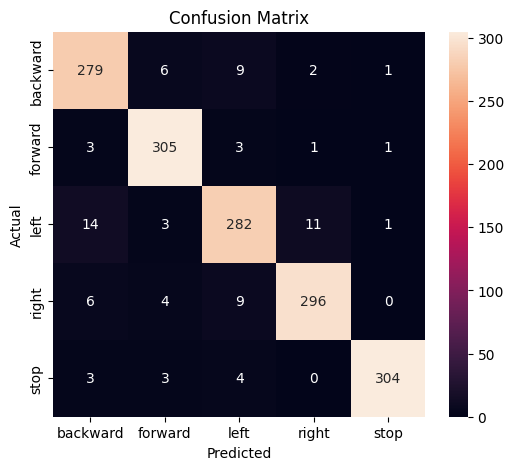

In [31]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val_encoded, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

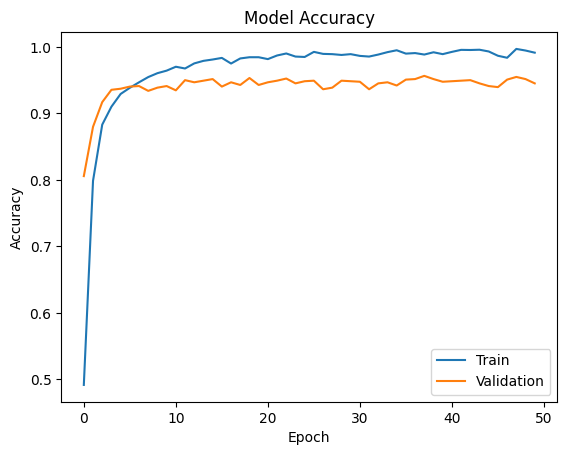

In [33]:
plt.figure()

# Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

plt.show()

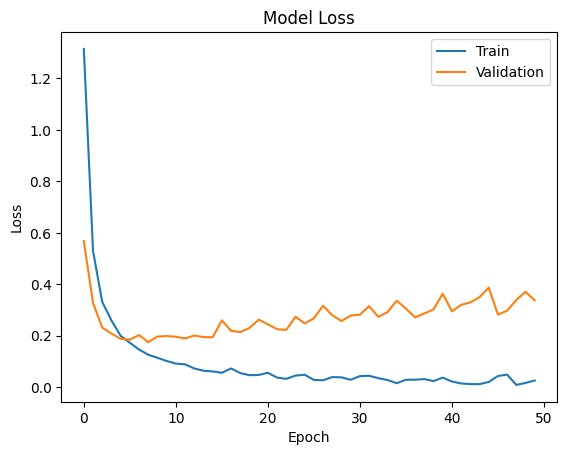

In [35]:
plt.figure()

# Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])

plt.show()

In [37]:
for i in range(len(y_pred)):
    if y_pred[i] != y_val_encoded[i]:
        print("Actual:", le.classes_[y_val_encoded[i]],
              "Predicted:", le.classes_[y_pred[i]])

Actual: forward Predicted: left
Actual: stop Predicted: backward
Actual: left Predicted: backward
Actual: forward Predicted: left
Actual: right Predicted: backward
Actual: left Predicted: right
Actual: right Predicted: left
Actual: left Predicted: backward
Actual: right Predicted: backward
Actual: left Predicted: right
Actual: right Predicted: backward
Actual: right Predicted: forward
Actual: right Predicted: left
Actual: forward Predicted: backward
Actual: backward Predicted: right
Actual: backward Predicted: right
Actual: left Predicted: backward
Actual: left Predicted: forward
Actual: backward Predicted: forward
Actual: forward Predicted: backward
Actual: forward Predicted: left
Actual: stop Predicted: left
Actual: stop Predicted: left
Actual: backward Predicted: left
Actual: left Predicted: backward
Actual: left Predicted: backward
Actual: backward Predicted: forward
Actual: right Predicted: backward
Actual: stop Predicted: backward
Actual: right Predicted: left
Actual: stop Predic

In [39]:
import tensorflow as tf

# Load model
model = tf.keras.models.load_model("voice_modelmodified.h5")

# Convert to TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Important Fix
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS
]

converter._experimental_lower_tensor_list_ops = False

# Convert
tflite_model = converter.convert()

# Save
with open("voice_modelmodified.tflite", "wb") as f:
    f.write(tflite_model)

print("✅ TFLite model created successfully")

INFO:tensorflow:Assets written to: C:\Users\narth\AppData\Local\Temp\tmpyykf8hcj\assets


INFO:tensorflow:Assets written to: C:\Users\narth\AppData\Local\Temp\tmpyykf8hcj\assets


✅ TFLite model created successfully
